# Long-Term Trend Analysis of Pettitt-Derived Melt Dates (1988–2022)
This section analyzes the 35-year trends in Pettitt-derived MOD, MED, and melt duration. Trend significance was evaluated using the Mann–Kendall test, and the magnitude of change was quantified using Sen’s slope. To ensure the robustness of long-term trends, the analysis was restricted to pixels with valid data for at least 30 out of the 35 years.

Although a significance level of 0.05 is commonly recommended, a more relaxed threshold of 0.2 was applied in this analysis to better visualize the spatial distribution of trend patterns.

In [1]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.feature as cfeature
import matplotlib.path as mpath
import matplotlib.patheffects as pe
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
import geopandas as gpd
from shapely.geometry import Point
from scipy.stats import linregress, spearmanr
from pymannkendall import original_test
import matplotlib.colors as mcolors
from scipy.stats import kendalltau

if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")

## Create the land mask for regions north of 60°N

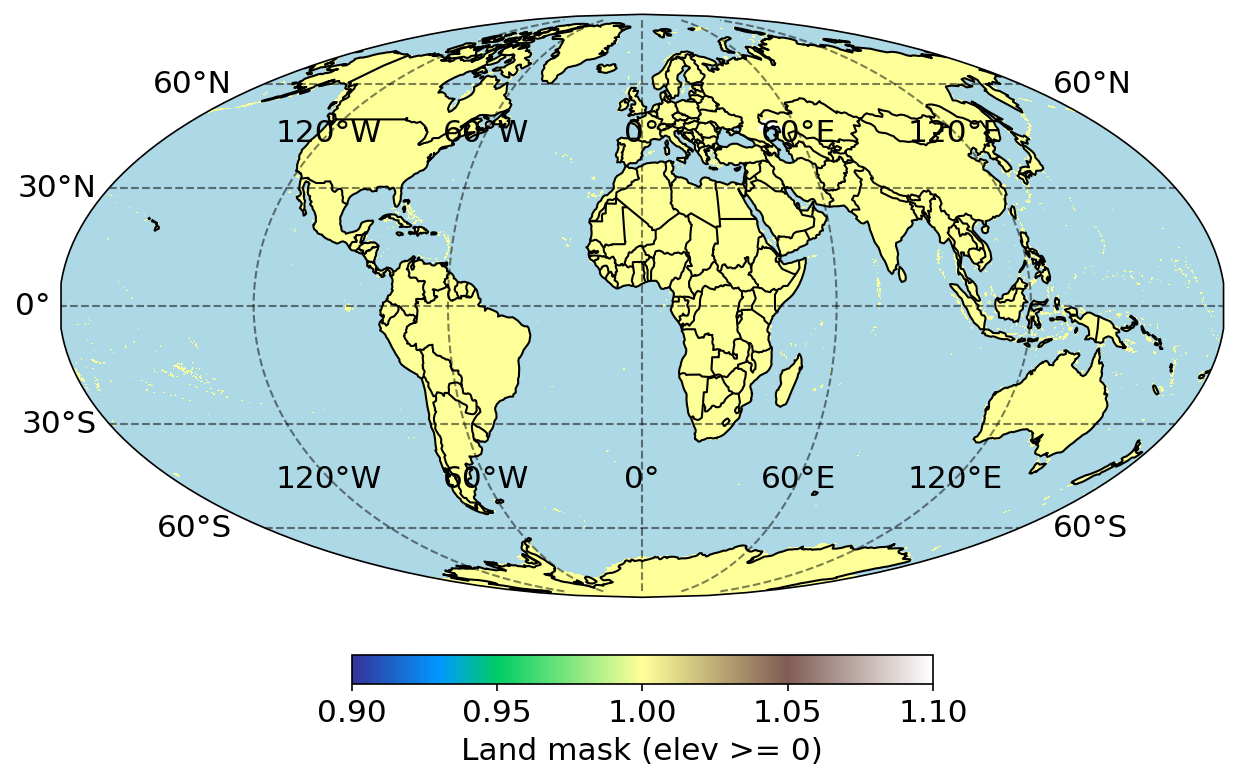

In [2]:
# Create land mask using DEM
domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

DEM_path = '/home/nayoung/nas_data/DEM'
Find_DEM_File = sorted(glob.glob(os.path.join(DEM_path, "*.nc")))
DEM_25km = nc.Dataset(Find_DEM_File[0])
with nc.Dataset(Find_DEM_File[0]) as ds:
    DEM_elev = ds.variables['elev'][:]      # (lat, lon)
    lat  = ds.variables['lat'][:]       # (lat,)
    lon  = ds.variables['lon'][:]       # (lon,)

land_mask = DEM_elev > 0
land_only = np.where(land_mask, 1, np.nan)

# Check the land mask for the entire world
hPlot.plot_map(domain_lon, domain_lat, land_only, np.nanmin(land_only), 1, plot_title="Land mask (elev >= 0)", label_title="Land mask (elev >= 0)", cmap='terrain')

# Extract the pixels in the range of 60N~90N
lat_mask_idx = np.where(lat >= 60)[0]

# Cut the pixels in the range of 60N~90N
elev_np = DEM_elev.filled(np.nan)  
elev_60N = elev_np[lat_mask_idx, :]

land_mask_60N_base = np.isfinite(elev_60N).astype(np.uint8) 

## Create a function to plot the North Polar region, as the study focuses on areas north of 60°N

In [3]:
def plot_Northpole(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None, markers=None):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    # Continuous/Discrete norm
    if bounds is None:
        if vcenter is None:
            norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    else:
        norm = mcolors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)
                
    gl.xlabel_style = {'size': 18}
    gl.ylabel_style = {'size': 18}

    gl.top_labels = False
    gl.right_labels = False

    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        pad=0.07, shrink=0.8, extend='both',
        boundaries=bounds if bounds is not None else None,
        ticks=ticks
    )
    cbar.set_label(label_title, fontsize=12, labelpad=10)
    cbar.ax.tick_params(labelsize=18)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)
    elif bounds is None:
        tick_values = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    if markers is not None:
        for m in markers:
            ax.scatter(
                m["lon"],
                m["lat"],
                transform=ccrs.PlateCarree(),
                marker=m.get("marker", "o"),
                s=m.get("size", 300),
                color=m.get("color", "red"),
                edgecolor=m.get("edgecolor", "black"),
                linewidth=m.get("linewidth", 1.4),
                zorder=20
            )

    if label_title is not None:
        ax.set_title(label_title, fontsize=16, pad=20)

    return fig, ax

## Load the data

In [4]:
Pettitt_MOD_file_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MOD_pettitt_250window_MA5_meanstd_1988_2022.nc'
PettittMED_file_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MED_pettitt_250window_MA5_meanstd_1988_2022.nc'
TB_cluster_map_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_cluster_map.nc'
permafrost_mask_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/Permafrost_waterbody_mask'

with nc.Dataset(Pettitt_MOD_file_path) as ds:
    MOD_doy = ds.variables['MOD_doy'][:]
    Tau = ds.variables['tau'][:]
    lon = ds.variables['lon'][:]
    lat = ds.variables['lat'][:]

with nc.Dataset(PettittMED_file_path) as ds:
    MED_doy = ds.variables['MED_doy'][:]

with nc.Dataset(TB_cluster_map_path) as ds:
    TB_cluster = ds.variables['TB_cluster'][:]  # (lat, lon)

## Define the functions required for the analysis

In [5]:
def load_mask_for_year(y):
    yfile = 1992 if y <= 1992 else y
    fpath = f"{permafrost_mask_path}/Permafrost_waterbody_mask_25km_{yfile}.nc"
    with nc.Dataset(fpath) as ds:
        snowice_mask = ds.variables['snowice_mask'][:]
        waterbody_mask = ds.variables['water_mask'][:]
    mask = np.isfinite(snowice_mask) & np.isfinite(waterbody_mask)
    return mask.astype(np.uint8)


def mann_kendall_test(y):
    """
    Returns tau, p-value
    """
    x = np.arange(len(y))
    mask = np.isfinite(y)
    if np.sum(mask) < 5:
        return np.nan, np.nan
    tau, p = kendalltau(x[mask], y[mask])
    return tau, p


def sens_slope(y):
    """
    Sen's slope (days/year)
    """
    mask = np.isfinite(y)
    y = y[mask]
    x = np.arange(len(y))

    if len(y) < 5:
        return np.nan

    slopes = []
    for i in range(len(y)-1):
        for j in range(i+1, len(y)):
            slopes.append((y[j] - y[i]) / (j - i))
    return np.median(slopes)

## 1. MOD Trend Analysis

In [6]:
# Define the start and end year
start_year, end_year = 1988, 2022
min_years = 30

if np.ma.isMaskedArray(MOD_doy):
    MOD_doy = MOD_doy.filled(np.nan)
MOD_doy = np.array(MOD_doy, dtype=np.float32, copy=True)

# Exclude cluster 3 globally
MOD_doy[TB_cluster == 3, :] = np.nan

# Analysis was restricted to DOY between 30 and 250.
MOD_doy[(MOD_doy < 30) | (MOD_doy > 250)] = np.nan

for yi, year in enumerate(range(start_year, end_year+1)):
    bad = (load_mask_for_year(year) == 0)
    slice_y = MOD_doy[:, :, yi]
    slice_y[bad] = np.nan
    MOD_doy[:, :, yi] = slice_y

lat_n, lon_n = MOD_doy.shape[:2]
mk_tau   = np.full((lat_n, lon_n), np.nan)
mk_p     = np.full((lat_n, lon_n), np.nan)
mk_trend = np.full((lat_n, lon_n), 0, dtype=np.int8)  
mk_slope = np.full((lat_n, lon_n), np.nan)            # Sen’s slope (days/year)

for i in range(lat_n):
    for j in range(lon_n):
        series = MOD_doy[i, j, :]
        valid = ~np.isnan(series)
        if np.count_nonzero(valid) < min_years:
            continue
        try:
            res = original_test(series[valid])
            mk_tau[i, j]   = res.Tau
            mk_p[i, j]     = res.p
            mk_trend[i, j] = 1 if res.trend == 'increasing' else (-1 if res.trend == 'decreasing' else 0)
            mk_slope[i, j] = res.slope      
        except Exception:
            pass

### Figure 3a. Sen’s slope of Pettitt-derived MOD, shown only for pixels significant at the 95% confidence level (p < 0.05)

Mean slope for 95% significant MOD (days/year): 0.002519299989775095
Median slope for 95% significant MOD (days/year): -0.3333333333333333
Total significant pixels: 3427
Decreasing pixels: 1762
Increasing pixels: 1665
No-trend pixels: 0


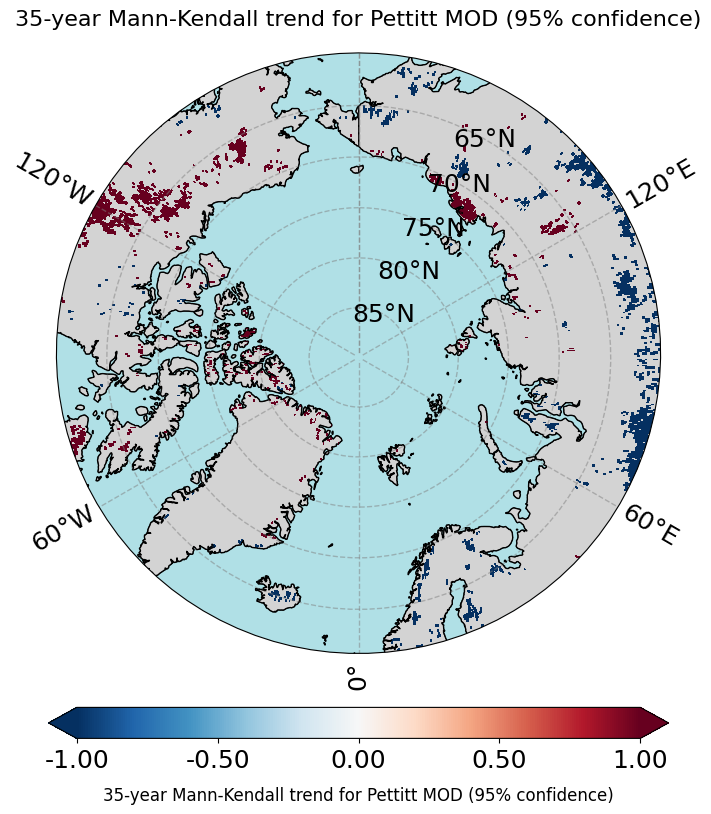

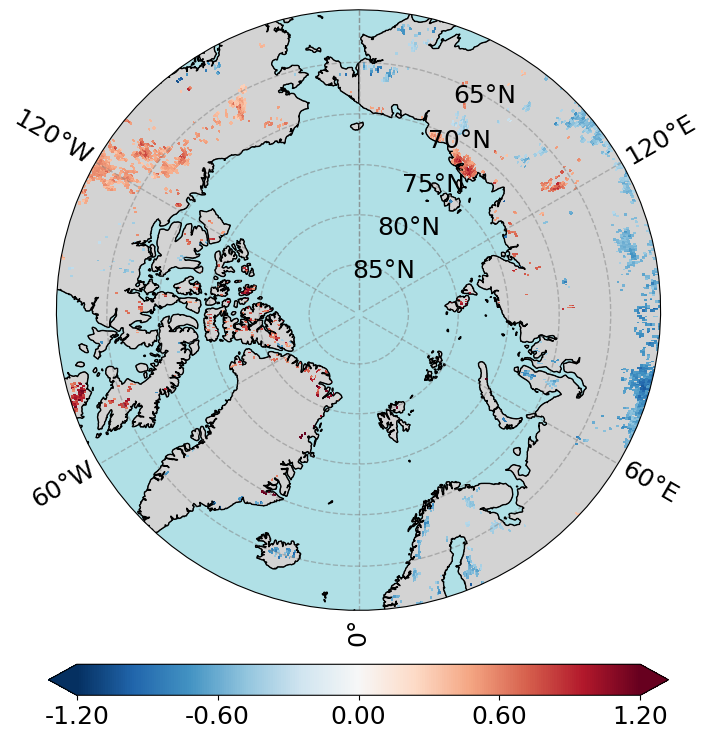

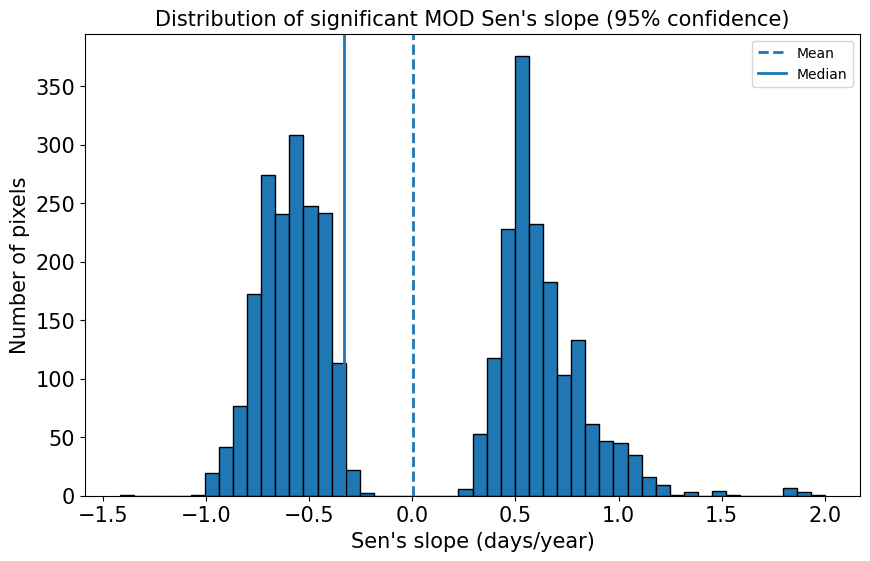

Total pixels in histogram: 3427


In [21]:
domain_lon, domain_lat = np.meshgrid(lon, lat)

significant_level = 0.05
confidence_level = int((1 - significant_level) * 100)

# Redefine significant trend direction using p-value and Sen's slope sign
mk_trend_redefined = np.full_like(mk_slope, np.nan, dtype=float)
mk_trend_redefined[(mk_p < significant_level) & (mk_slope < 0)] = -1
mk_trend_redefined[(mk_p < significant_level) & (mk_slope > 0)] = 1
mk_trend_redefined[(mk_p < significant_level) & (mk_slope == 0)] = 0

# Significant Sen's slope
mk_slope_significant = np.where(mk_p < significant_level, mk_slope, np.nan)

# Plot trend direction
fig_trend, ax_trend = plot_Northpole(
    domain_lon, domain_lat, mk_trend_redefined,
    label_title=f"35-year Mann-Kendall trend for Pettitt MOD ({confidence_level}% confidence)",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    vcenter=0
)

# Plot Sen's slope
fig_slope, ax_slope = plot_Northpole(
    domain_lon, domain_lat, mk_slope_significant,
    label_title=None,
    cmap="RdBu_r",
    vmin=-1.2,
    vmax=1.2,
    vcenter=0
)

# Save the figure
fig_slope.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/MOD_slope_significant_95percent.png", dpi=300, bbox_inches="tight")


# Statistics
slope_vals = mk_slope_significant[np.isfinite(mk_slope_significant)]

print(f"Mean slope for {confidence_level}% significant MOD (days/year):", np.nanmean(slope_vals))
print(f"Median slope for {confidence_level}% significant MOD (days/year):", np.nanmedian(slope_vals))

total_significant_pixels = np.sum(np.isfinite(mk_trend_redefined))
decreasing_pixels = np.sum(mk_trend_redefined == -1)
increasing_pixels = np.sum(mk_trend_redefined == 1)
no_trend_pixels = np.sum(mk_trend_redefined == 0)

print(f"Total significant pixels: {total_significant_pixels}")
print(f"Decreasing pixels: {decreasing_pixels}")
print(f"Increasing pixels: {increasing_pixels}")
print(f"No-trend pixels: {no_trend_pixels}")

# Histogram
plt.figure(figsize=(10, 6))
plt.hist(slope_vals, bins=50, edgecolor="black")
plt.axvline(np.nanmean(slope_vals), linestyle="--", linewidth=2, label="Mean")
plt.axvline(np.nanmedian(slope_vals), linestyle="-", linewidth=2, label="Median")

plt.xlabel("Sen's slope (days/year)")
plt.ylabel("Number of pixels")
plt.title(f"Distribution of significant MOD Sen's slope ({confidence_level}% confidence)")
plt.legend()
plt.show()

print("Total pixels in histogram:", slope_vals.size)

In [51]:
def plot_slope_histogram_by_regime(
    mk_slope_significant,
    TB_cluster,
    metric_name,
    confidence_level,
    out_dir,
):

    regime_names = {
        0: "HT",
        1: "PT",
        2: "MT",
    }

    regime_colors = {
        0: "red",
        1: "gold",
        2: "yellowgreen",
    }

    plt.figure(figsize=(14, 8))

    slope_vals = mk_slope_significant[np.isfinite(mk_slope_significant)]

    # Same style as original histogram
    bins = np.linspace(
        np.nanmin(slope_vals),
        np.nanmax(slope_vals),
        50
    )

    legend_handles = []
    legend_labels = []

    # =========================================================
    # Histograms + regime medians
    # =========================================================
    for rid in [0, 1, 2]:

        mask = (
            np.isfinite(mk_slope_significant)
            & (TB_cluster == rid)
        )

        regime_slopes = mk_slope_significant[mask]

        # Histogram
        hist = plt.hist(
            regime_slopes,
            bins=bins,
            alpha=0.55,
            edgecolor="black",
            linewidth=0.7,
            color=regime_colors[rid],
        )

        legend_handles.append(hist[2][0])
        legend_labels.append(
            f"{regime_names[rid]} (n={np.sum(mask):,})"
        )

        # -----------------------------------------------------
        # Negative / positive slopes
        # -----------------------------------------------------
        negative_slopes = regime_slopes[regime_slopes < 0]
        positive_slopes = regime_slopes[regime_slopes > 0]

        # Negative median
        if len(negative_slopes) > 0:

            negative_median = np.nanmedian(negative_slopes)

            line = plt.axvline(
                negative_median,
                color=regime_colors[rid],
                linestyle="-",
                linewidth=3,
                alpha=0.95,
            )

            legend_handles.append(line)
            legend_labels.append(
                f"{regime_names[rid]} negative median ({negative_median:.2f})"
            )

        # Positive median
        if len(positive_slopes) > 0:

            positive_median = np.nanmedian(positive_slopes)

            line = plt.axvline(
                positive_median,
                color=regime_colors[rid],
                linestyle="--",
                linewidth=3,
                alpha=0.95,
            )

            legend_handles.append(line)
            legend_labels.append(
                f"{regime_names[rid]} positive median ({positive_median:.2f})"
            )

    # =========================================================
    # Overall statistics
    # =========================================================
    overall_mean = np.nanmean(slope_vals)

    overall_mean_line = plt.axvline(
        overall_mean,
        color="black",
        linestyle=":",
        linewidth=3,
    )

    legend_handles.append(overall_mean_line)
    legend_labels.append(
        f"Overall mean ({overall_mean:.3f})"
    )

    # Overall median
    overall_median = np.nanmedian(slope_vals)

    overall_median_line = plt.axvline(
        overall_median,
        color="black",
        linestyle="-.",
        linewidth=3,
    )

    legend_handles.append(overall_median_line)
    legend_labels.append(
        f"Overall median ({overall_median:.2f})"
    )

    # =========================================================
    # Labels
    # =========================================================
    plt.xlabel(
        "Sen's slope (days/year)",
        fontsize=30
    )

    plt.ylabel(
        "Number of pixels",
        fontsize=30
    )

    plt.xticks(fontsize=25)
    plt.yticks(fontsize=25)

    # =========================================================
    # Legend
    # =========================================================
    plt.legend(
        legend_handles,
        legend_labels,
        fontsize=18,
        frameon=True
    )

    plt.tight_layout()

    # =========================================================
    # Save
    # =========================================================
    save_path = (
        f"{out_dir}/"
        f"{metric_name}_slope_95percent_histogram.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {save_path}")



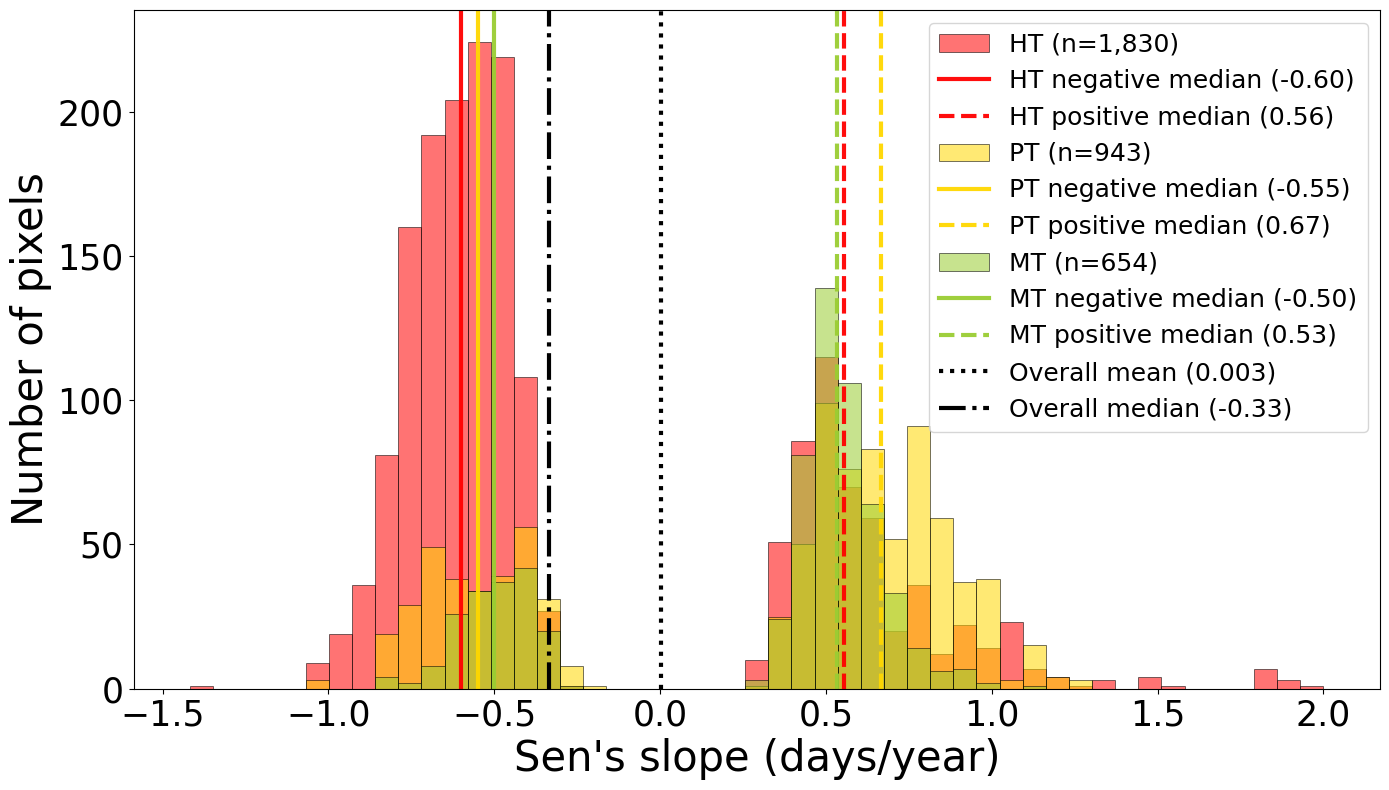

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/MOD_slope_95percent_histogram.png


In [52]:
out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend"

plot_slope_histogram_by_regime(
    mk_slope_significant=mk_slope_significant,
    TB_cluster=TB_cluster,
    metric_name="MOD",
    confidence_level=confidence_level,
    out_dir=out_dir,
)


### Pettitt-derived MOD trends for each Regime

In [8]:
def find_extreme_pixel_by_regime(
    slope,
    p_value,
    cluster_map,
    domain_lon,
    domain_lat,
    cid,
    significant_level=0.2,
    mode="decrease"
):
    """
    Find the strongest increasing/decreasing significant pixel within one regime.
    """

    regime_mask = (cluster_map == cid)
    sig_mask = (p_value < significant_level)

    valid_mask = regime_mask & sig_mask & np.isfinite(slope)
    candidate = np.where(valid_mask, slope, np.nan)

    if np.all(np.isnan(candidate)):
        return None

    if mode == "decrease":
        i, j = np.unravel_index(np.nanargmin(candidate), candidate.shape)
    elif mode == "increase":
        i, j = np.unravel_index(np.nanargmax(candidate), candidate.shape)
    else:
        raise ValueError("mode must be 'decrease' or 'increase'")

    return {
        "cid": cid,
        "mode": mode,
        "center_i": i,
        "center_j": j,
        "center_lon": domain_lon[i, j],
        "center_lat": domain_lat[i, j],
        "center_slope": slope[i, j],
        "center_p": p_value[i, j]
    }



def plot_all_significant_trend_pixels_by_regime(
    md_data,
    years,
    slope,
    p_value,
    trend,
    cluster_map,
    cluster_name_map,
    significant_level=0.2,
    error_type="std",   # "std", "se", or None
    title="MOD significant trend-pixel mean time series",
    ylabel="MOD DOY",
    save_path=None
):
    """
    Plot mean time series for all significant decreasing/increasing pixels
    within each regime.

    For each regime and trend direction:
    - decrease: p < significant_level and slope < 0
    - increase: p < significant_level and slope > 0

    The trend statistics in the label are recalculated from the mean time series.
    """

    years = np.asarray(years)

    if md_data.shape[0] == len(years):
        data_order = "time_lat_lon"
    elif md_data.shape[-1] == len(years):
        data_order = "lat_lon_time"
    else:
        raise ValueError("Cannot determine time dimension.")

    color_map = {
        0: "blue",
        1: "orange",
        2: "green"
    }

    mode_title_map = {
        "decrease": "All significant decreasing pixels",
        "increase": "All significant increasing pixels"
    }

    fig, axes = plt.subplots(
        2, 1,
        figsize=(40, 30),
        sharex=True,
        constrained_layout=True
    )

    for ax, mode in zip(axes, ["decrease", "increase"]):

        for cid in [0, 1, 2]:

            if mode == "decrease":
                trend_mask = slope < 0
            elif mode == "increase":
                trend_mask = slope > 0
            else:
                raise ValueError("mode must be 'decrease' or 'increase'")

            pixel_mask = (
                (cluster_map == cid) &
                (p_value < significant_level) &
                np.isfinite(slope) &
                trend_mask
            )

            n_used = np.sum(pixel_mask)

            if n_used == 0:
                continue

            if data_order == "time_lat_lon":
                masked_data = np.where(
                    pixel_mask[None, :, :],
                    md_data,
                    np.nan
                )

                y = np.nanmean(masked_data, axis=(1, 2))
                y_std = np.nanstd(masked_data, axis=(1, 2))
                y_count = np.sum(np.isfinite(masked_data), axis=(1, 2))

            else:
                masked_data = np.where(
                    pixel_mask[:, :, None],
                    md_data,
                    np.nan
                )

                y = np.nanmean(masked_data, axis=(0, 1))
                y_std = np.nanstd(masked_data, axis=(0, 1))
                y_count = np.sum(np.isfinite(masked_data), axis=(0, 1))

            if error_type == "std":
                y_err = y_std
                err_label = "STD"
            elif error_type == "se":
                y_err = y_std / np.sqrt(y_count)
                err_label = "SE"
            else:
                y_err = None
                err_label = None

            valid = np.isfinite(y)

            if np.sum(valid) < 3:
                continue

            mk_result = original_test(y[valid])
            sen_slope = mk_result.slope
            mk_p = mk_result.p

            intercept = np.nanmedian(
                y[valid] - sen_slope * years[valid]
            )

            y_fit = intercept + sen_slope * years

            if abs(sen_slope) < 0.001:
                sen_slope_text = "< 0.001"
            else:
                sen_slope_text = f"{sen_slope:.2f}"

            if mk_p < 0.001:
                p_text = "<0.001"
            else:
                p_text = f"{mk_p:.3f}"

            label = (
                f"{cluster_name_map[cid]} "
                f"(Sen={sen_slope_text} d/yr, "
                f"p={p_text}, "
                f"n={n_used})"
            )

            if y_err is not None:
                ax.fill_between(
                    years,
                    y - y_err,
                    y + y_err,
                    color=color_map[cid],
                    alpha=0.18
                )

            ax.plot(
                years,
                y,
                marker="o",
                linestyle="-",
                linewidth=4.0,
                markersize=10,
                color=color_map[cid],
                label=label
            )

            ax.plot(
                years,
                y_fit,
                linestyle="--",
                linewidth=2.8,
                color=color_map[cid],
                alpha=0.9
            )

        ax.set_title(
            mode_title_map[mode],
            fontsize=80,
            weight="bold",
            pad=25
        )

        ax.set_ylabel(ylabel, fontsize=60)
        ax.tick_params(axis="both", labelsize=60)
        ax.grid(True, alpha=0.3)

        ax.legend(
            fontsize=60,
            frameon=True,
            framealpha=0.3,
            fancybox=True,
            edgecolor="black",
            loc="best",
        )

    axes[-1].set_xlabel("Year", fontsize=60)

    fig.suptitle(
        title,
        fontsize=80,
        weight="bold"
    )

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    return fig, axes


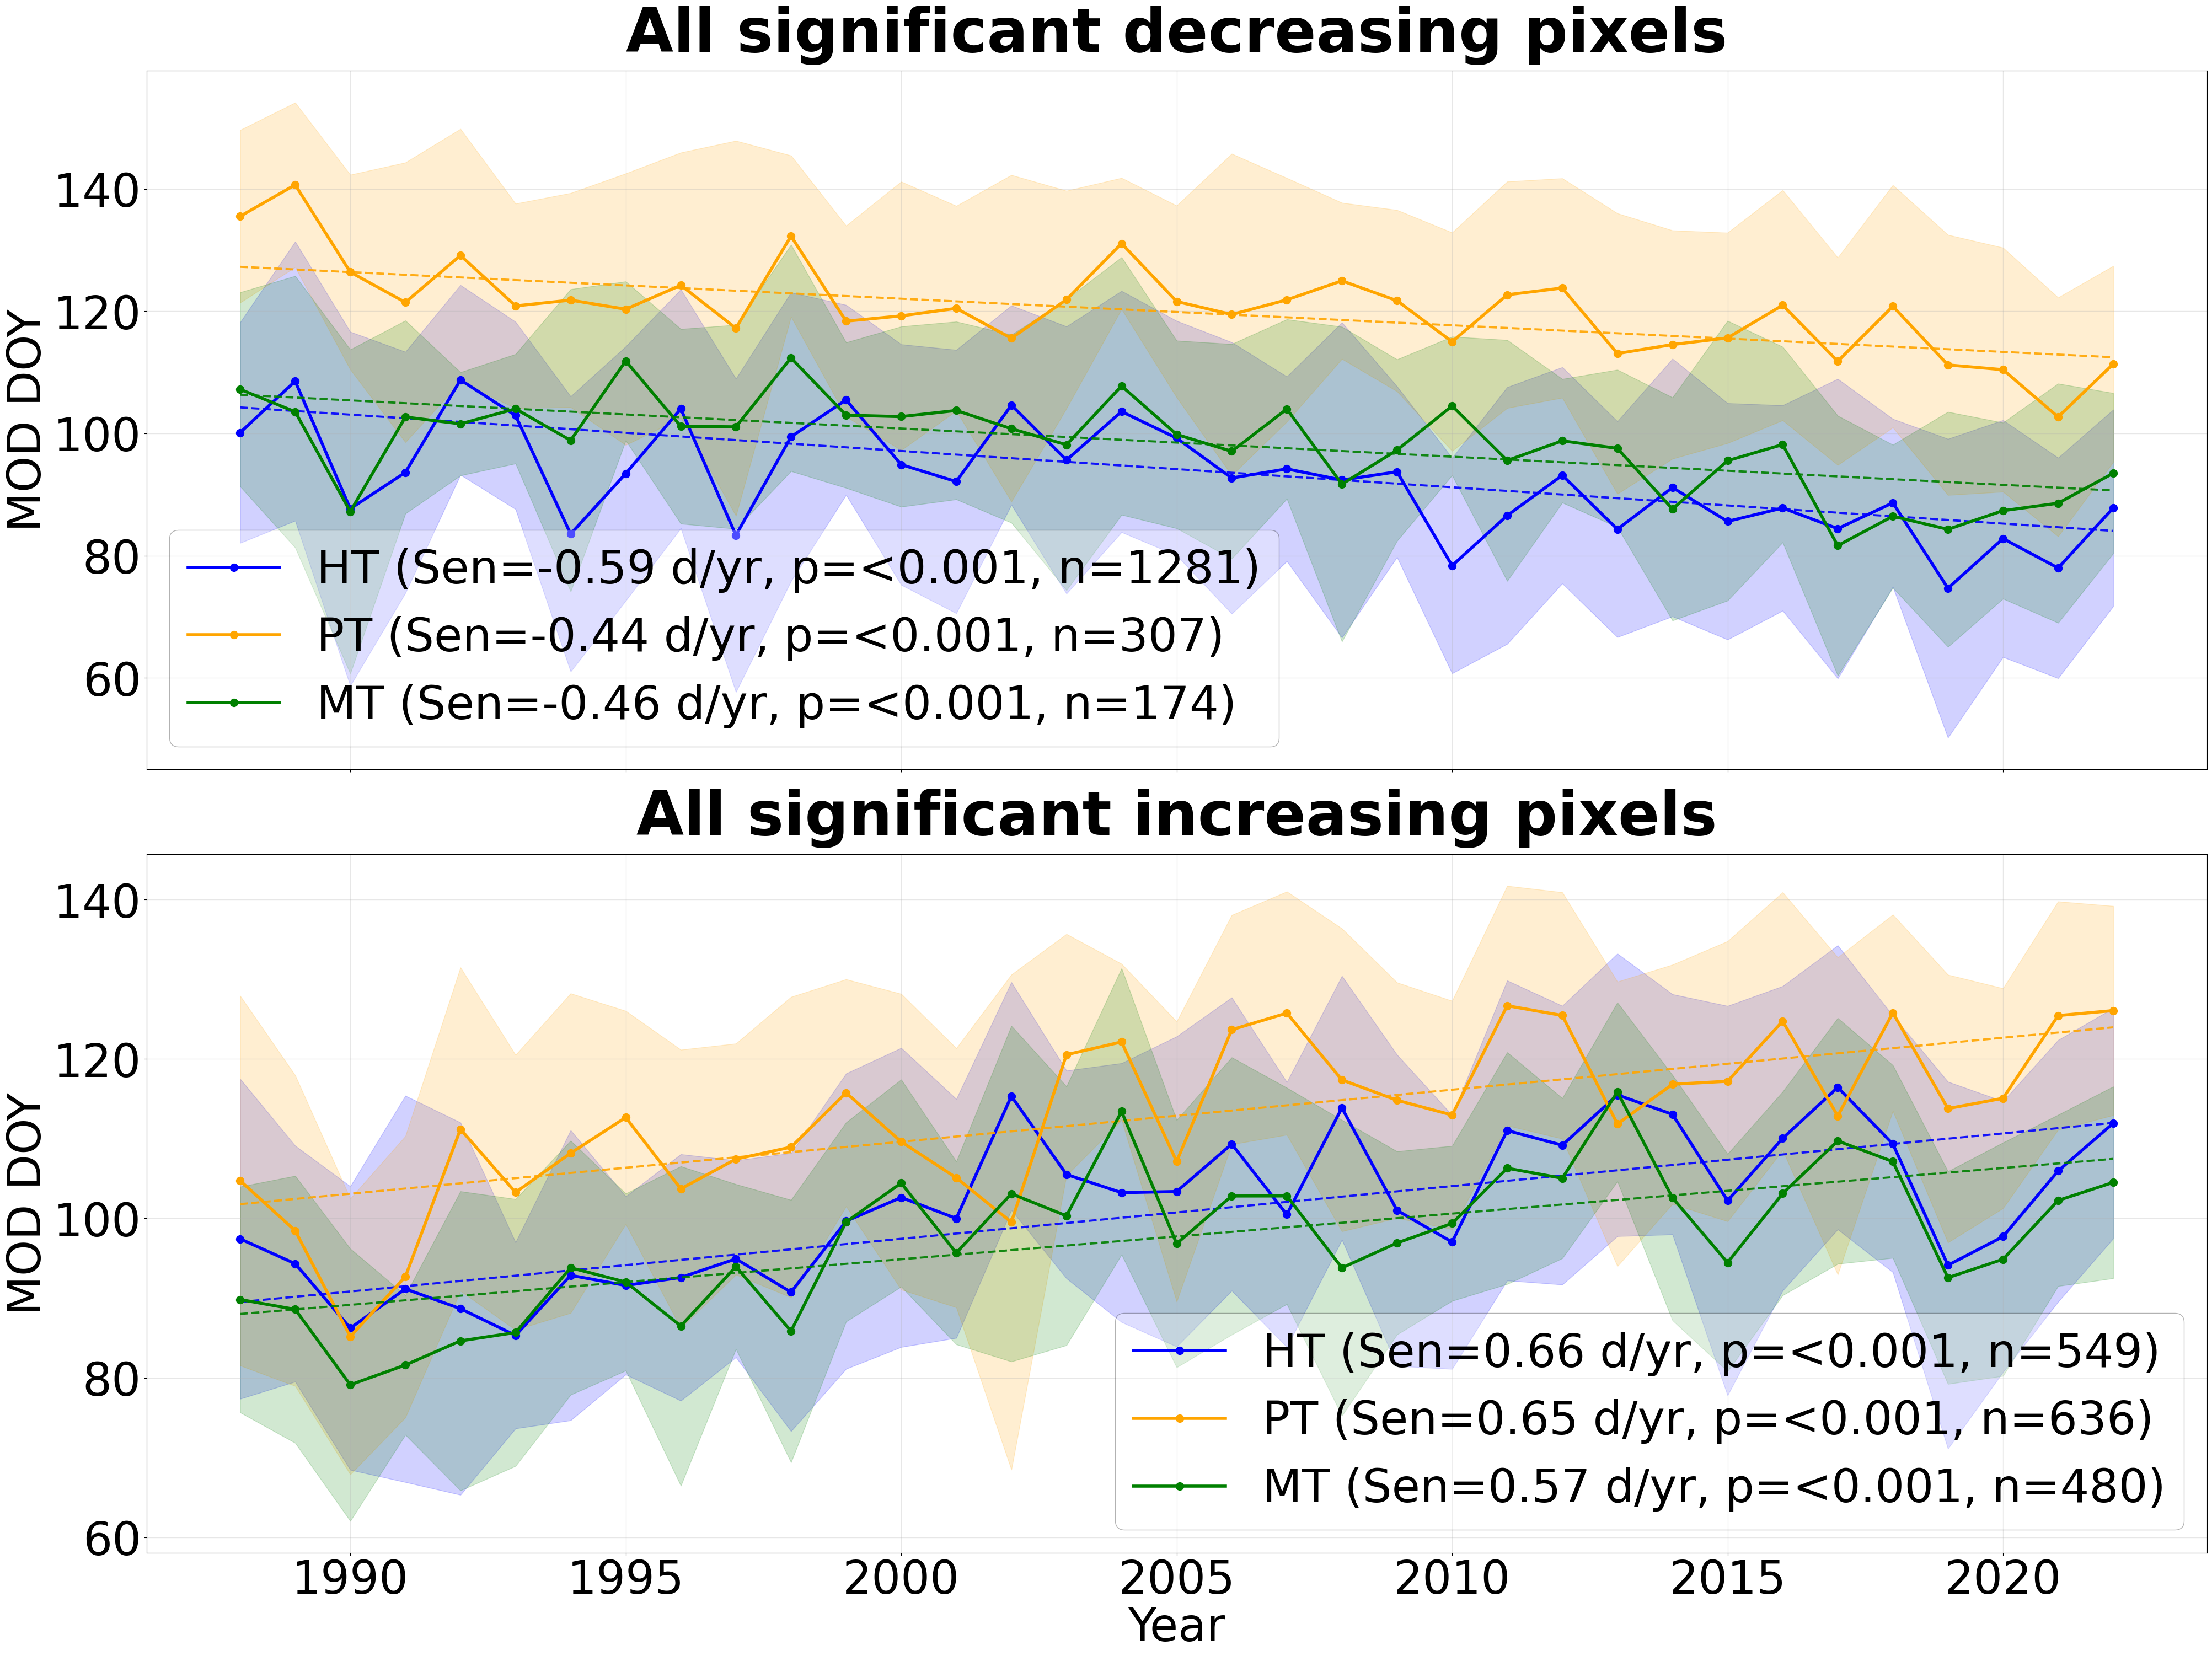

In [9]:
cluster_name_map = {0: "HT", 1: "PT", 2: "MT"}
marker_color_map = {0: "blue", 1: "orange", 2: "green"}
marker_symbol_map = {"increase": "^", "decrease": "v"} # Increase: upward triangle, Decrease: downward triangle
out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend"
os.makedirs(out_dir, exist_ok=True)

fig, axes = plot_all_significant_trend_pixels_by_regime(
    md_data=MOD_doy,
    years=np.arange(1988, 2023),
    slope=mk_slope,
    p_value=mk_p,
    trend=mk_trend,
    cluster_map=TB_cluster,
    cluster_name_map=cluster_name_map,
    significant_level=0.05,
    error_type="std",
    title=None,
    ylabel="MOD DOY",
    save_path=f"{out_dir}/MOD_all_significant_increasing_decreasing_pixels_by_regime.png"
)

### Figure 3d. Plot the p-value map, showing only statistically significant values

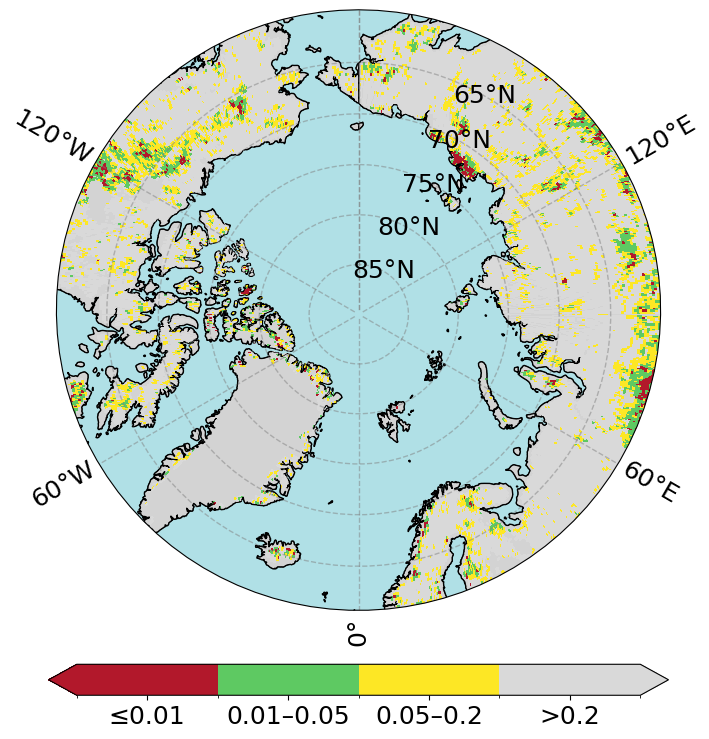

In [10]:
# Divide the pvalue into 0.01, 0.05 and 0.2
mk_p_class = np.full_like(mk_p, np.nan)

mk_p_class[mk_p <= 0.01] = 0
mk_p_class[(mk_p > 0.01) & (mk_p <= 0.05)] = 1
mk_p_class[(mk_p > 0.05) & (mk_p <= 0.2)] = 2
mk_p_class[mk_p > 0.2] = 3

color_list = [
    "#b2182b",
    "#5ec962",
    "#fde725",
    "#d9d9d9"
]

cmap = mcolors.ListedColormap(color_list)

bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
ticks = [0, 1, 2, 3]
ticklabels = ["≤0.01", "0.01–0.05", "0.05–0.2", ">0.2"]

plot_Northpole(domain_lon, domain_lat, mk_p_class, label_title=None, cmap=cmap, bounds=bounds, ticks=ticks, ticklabels=ticklabels)

fig, ax = plot_Northpole(
    domain_lon, domain_lat, mk_p_class,
    label_title=None,
    cmap=cmap,
    bounds=bounds,
    ticks=ticks,
    ticklabels=ticklabels
)

# Save the figure
fig.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/MOD_pvalue_map.png", dpi=300, bbox_inches="tight")
plt.close(fig)

## 2. MED Trend Analysis

In [11]:
# Define the start and end year
start_year, end_year = 1988, 2022
min_years = 30

if np.ma.isMaskedArray(MED_doy):
    MED_doy = MED_doy.filled(np.nan)
MED_doy = np.array(MED_doy, dtype=np.float32, copy=True)

# Exclude cluster 3 globally
MED_doy[TB_cluster == 3, :] = np.nan

# Only for DOY < 250
MED_doy[(MED_doy > 250)] = np.nan

for yi, year in enumerate(range(start_year, end_year+1)):
    bad = (load_mask_for_year(year) == 0)
    slice_y = MED_doy[:, :, yi]
    slice_y[bad] = np.nan
    MED_doy[:, :, yi] = slice_y

lat_n, lon_n = MED_doy.shape[:2]
mk_tau_med   = np.full((lat_n, lon_n), np.nan)
mk_p_med     = np.full((lat_n, lon_n), np.nan)
mk_trend_med = np.full((lat_n, lon_n), 0, dtype=np.int8)  
mk_slope_med = np.full((lat_n, lon_n), np.nan)            # Sen’s slope (days/year)

for i in range(lat_n):
    for j in range(lon_n):
        series = MED_doy[i, j, :]
        valid = ~np.isnan(series)
        if np.count_nonzero(valid) < min_years:
            continue
        try:
            res = original_test(series[valid])
            mk_tau_med[i, j]   = res.Tau
            mk_p_med[i, j]     = res.p
            mk_trend_med[i, j] = 1 if res.trend == 'increasing' else (-1 if res.trend == 'decreasing' else 0)
            mk_slope_med[i, j] = res.slope      
        except Exception:
            pass

### Figure 3b. Sen’s slope of Pettitt-derived MED, shown only for pixels significant at the 95% confidence level (p < 0.05)

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/MED_SenSlope_95percent.png
Mean slope for 95% significant MED (days/year): -0.30828814643013197
Median slope for 95% significant MED (days/year): -0.38095238095238093
Total significant pixels (p < 0.05): 12321
Number of decreasing pixels: 10958
Number of increasing pixels: 1363
Number of no-trend pixels: 0


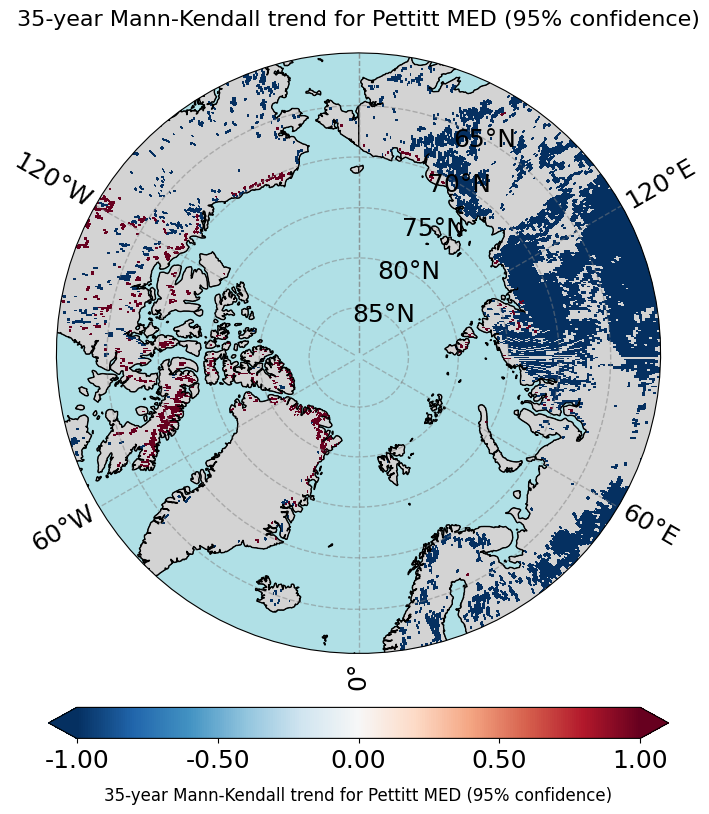

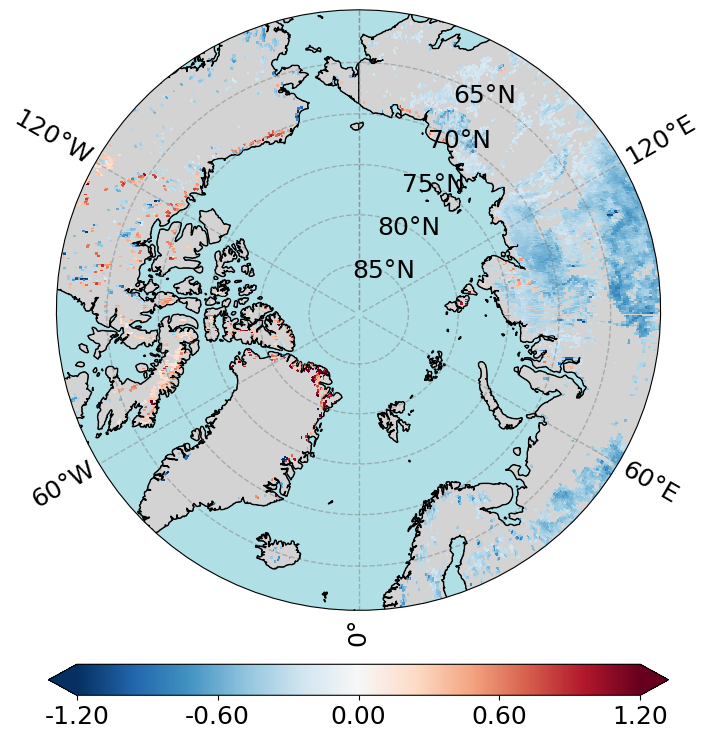

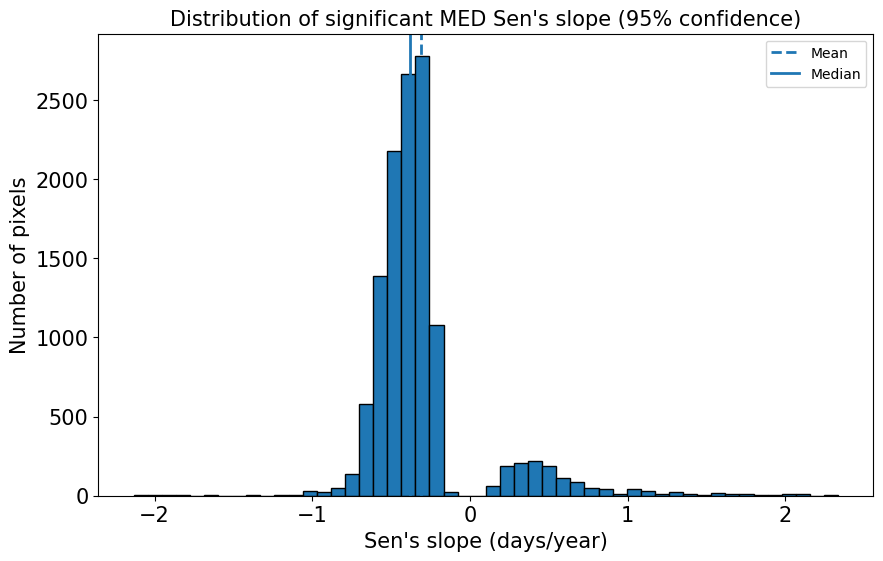

Total pixels in histogram: 12321


In [12]:
domain_lon, domain_lat = np.meshgrid(lon, lat)

# 1. Set significance level
significant_level_med = 0.05
confidence_level_med = int((1 - significant_level_med) * 100)

# 2. Redefine significant trend direction using p-value and Sen's slope sign
mk_trend_redefined_med = np.full(mk_slope_med.shape, np.nan, dtype=float)

mk_trend_redefined_med[(mk_p_med < significant_level_med) & (mk_slope_med < 0)] = -1
mk_trend_redefined_med[(mk_p_med < significant_level_med) & (mk_slope_med > 0)] = 1
mk_trend_redefined_med[(mk_p_med < significant_level_med) & (mk_slope_med == 0)] = 0

# 3. Plot trend direction
fig_trend_med, ax_trend_med = plot_Northpole(
    domain_lon,
    domain_lat,
    mk_trend_redefined_med,
    label_title=f"35-year Mann-Kendall trend for Pettitt MED ({confidence_level_med}% confidence)",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    vcenter=0
)

# 4. Plot Sen's slope with only significant pixels
mk_slope_significant_med = np.where(
    mk_p_med < significant_level_med,
    mk_slope_med,
    np.nan
)

fig_slope_med, ax_slope_med = plot_Northpole(
    domain_lon,
    domain_lat,
    mk_slope_significant_med,
    label_title=None,
    cmap="RdBu_r",
    vmin=-1.2,
    vmax=1.2,
    vcenter=0
)

# 5. Save the slope figure
out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend"
out_png = os.path.join(out_dir, f"MED_SenSlope_{confidence_level_med}percent.png")

fig_slope_med.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

print("Saved:", out_png)

# 6. Statistics
slope_vals_med = mk_slope_significant_med[np.isfinite(mk_slope_significant_med)]

print(f"Mean slope for {confidence_level_med}% significant MED (days/year):", np.nanmean(slope_vals_med))
print(f"Median slope for {confidence_level_med}% significant MED (days/year):", np.nanmedian(slope_vals_med))

# 7. Count decreasing/increasing pixels
total_significant_pixels_med = np.sum(np.isfinite(mk_trend_redefined_med))
decreasing_pixels_med = np.sum(mk_trend_redefined_med == -1)
increasing_pixels_med = np.sum(mk_trend_redefined_med == 1)
no_trend_pixels_med = np.sum(mk_trend_redefined_med == 0)

print(f"Total significant pixels (p < {significant_level_med}): {total_significant_pixels_med}")
print(f"Number of decreasing pixels: {decreasing_pixels_med}")
print(f"Number of increasing pixels: {increasing_pixels_med}")
print(f"Number of no-trend pixels: {no_trend_pixels_med}")

if total_significant_pixels_med != (
    decreasing_pixels_med + increasing_pixels_med + no_trend_pixels_med
):
    print("Warning: Pixel count mismatch!")

# 8. Histogram of significant Sen's slope values
plt.figure(figsize=(10, 6))
plt.hist(slope_vals_med, bins=50, edgecolor="black")
plt.axvline(np.nanmean(slope_vals_med), linestyle="--", linewidth=2, label="Mean")
plt.axvline(np.nanmedian(slope_vals_med), linestyle="-", linewidth=2, label="Median")

plt.xlabel("Sen's slope (days/year)")
plt.ylabel("Number of pixels")
plt.title(f"Distribution of significant MED Sen's slope ({confidence_level_med}% confidence)")
plt.legend()
plt.show()

print("Total pixels in histogram:", slope_vals_med.size)


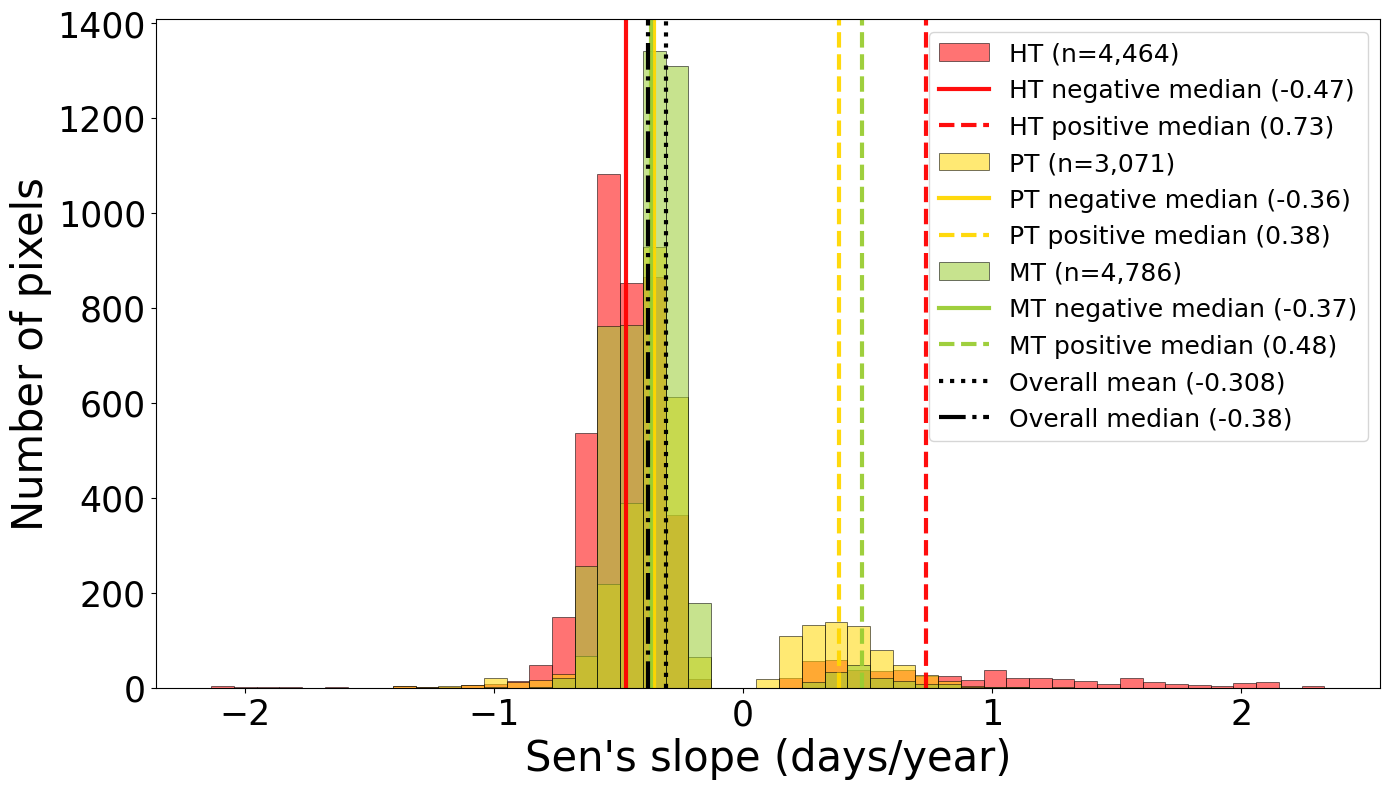

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/MED_slope_95percent_histogram.png


In [53]:
out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend"

plot_slope_histogram_by_regime(
    mk_slope_significant=mk_slope_significant_med,
    TB_cluster=TB_cluster,
    metric_name="MED",
    confidence_level=confidence_level,
    out_dir=out_dir,
)

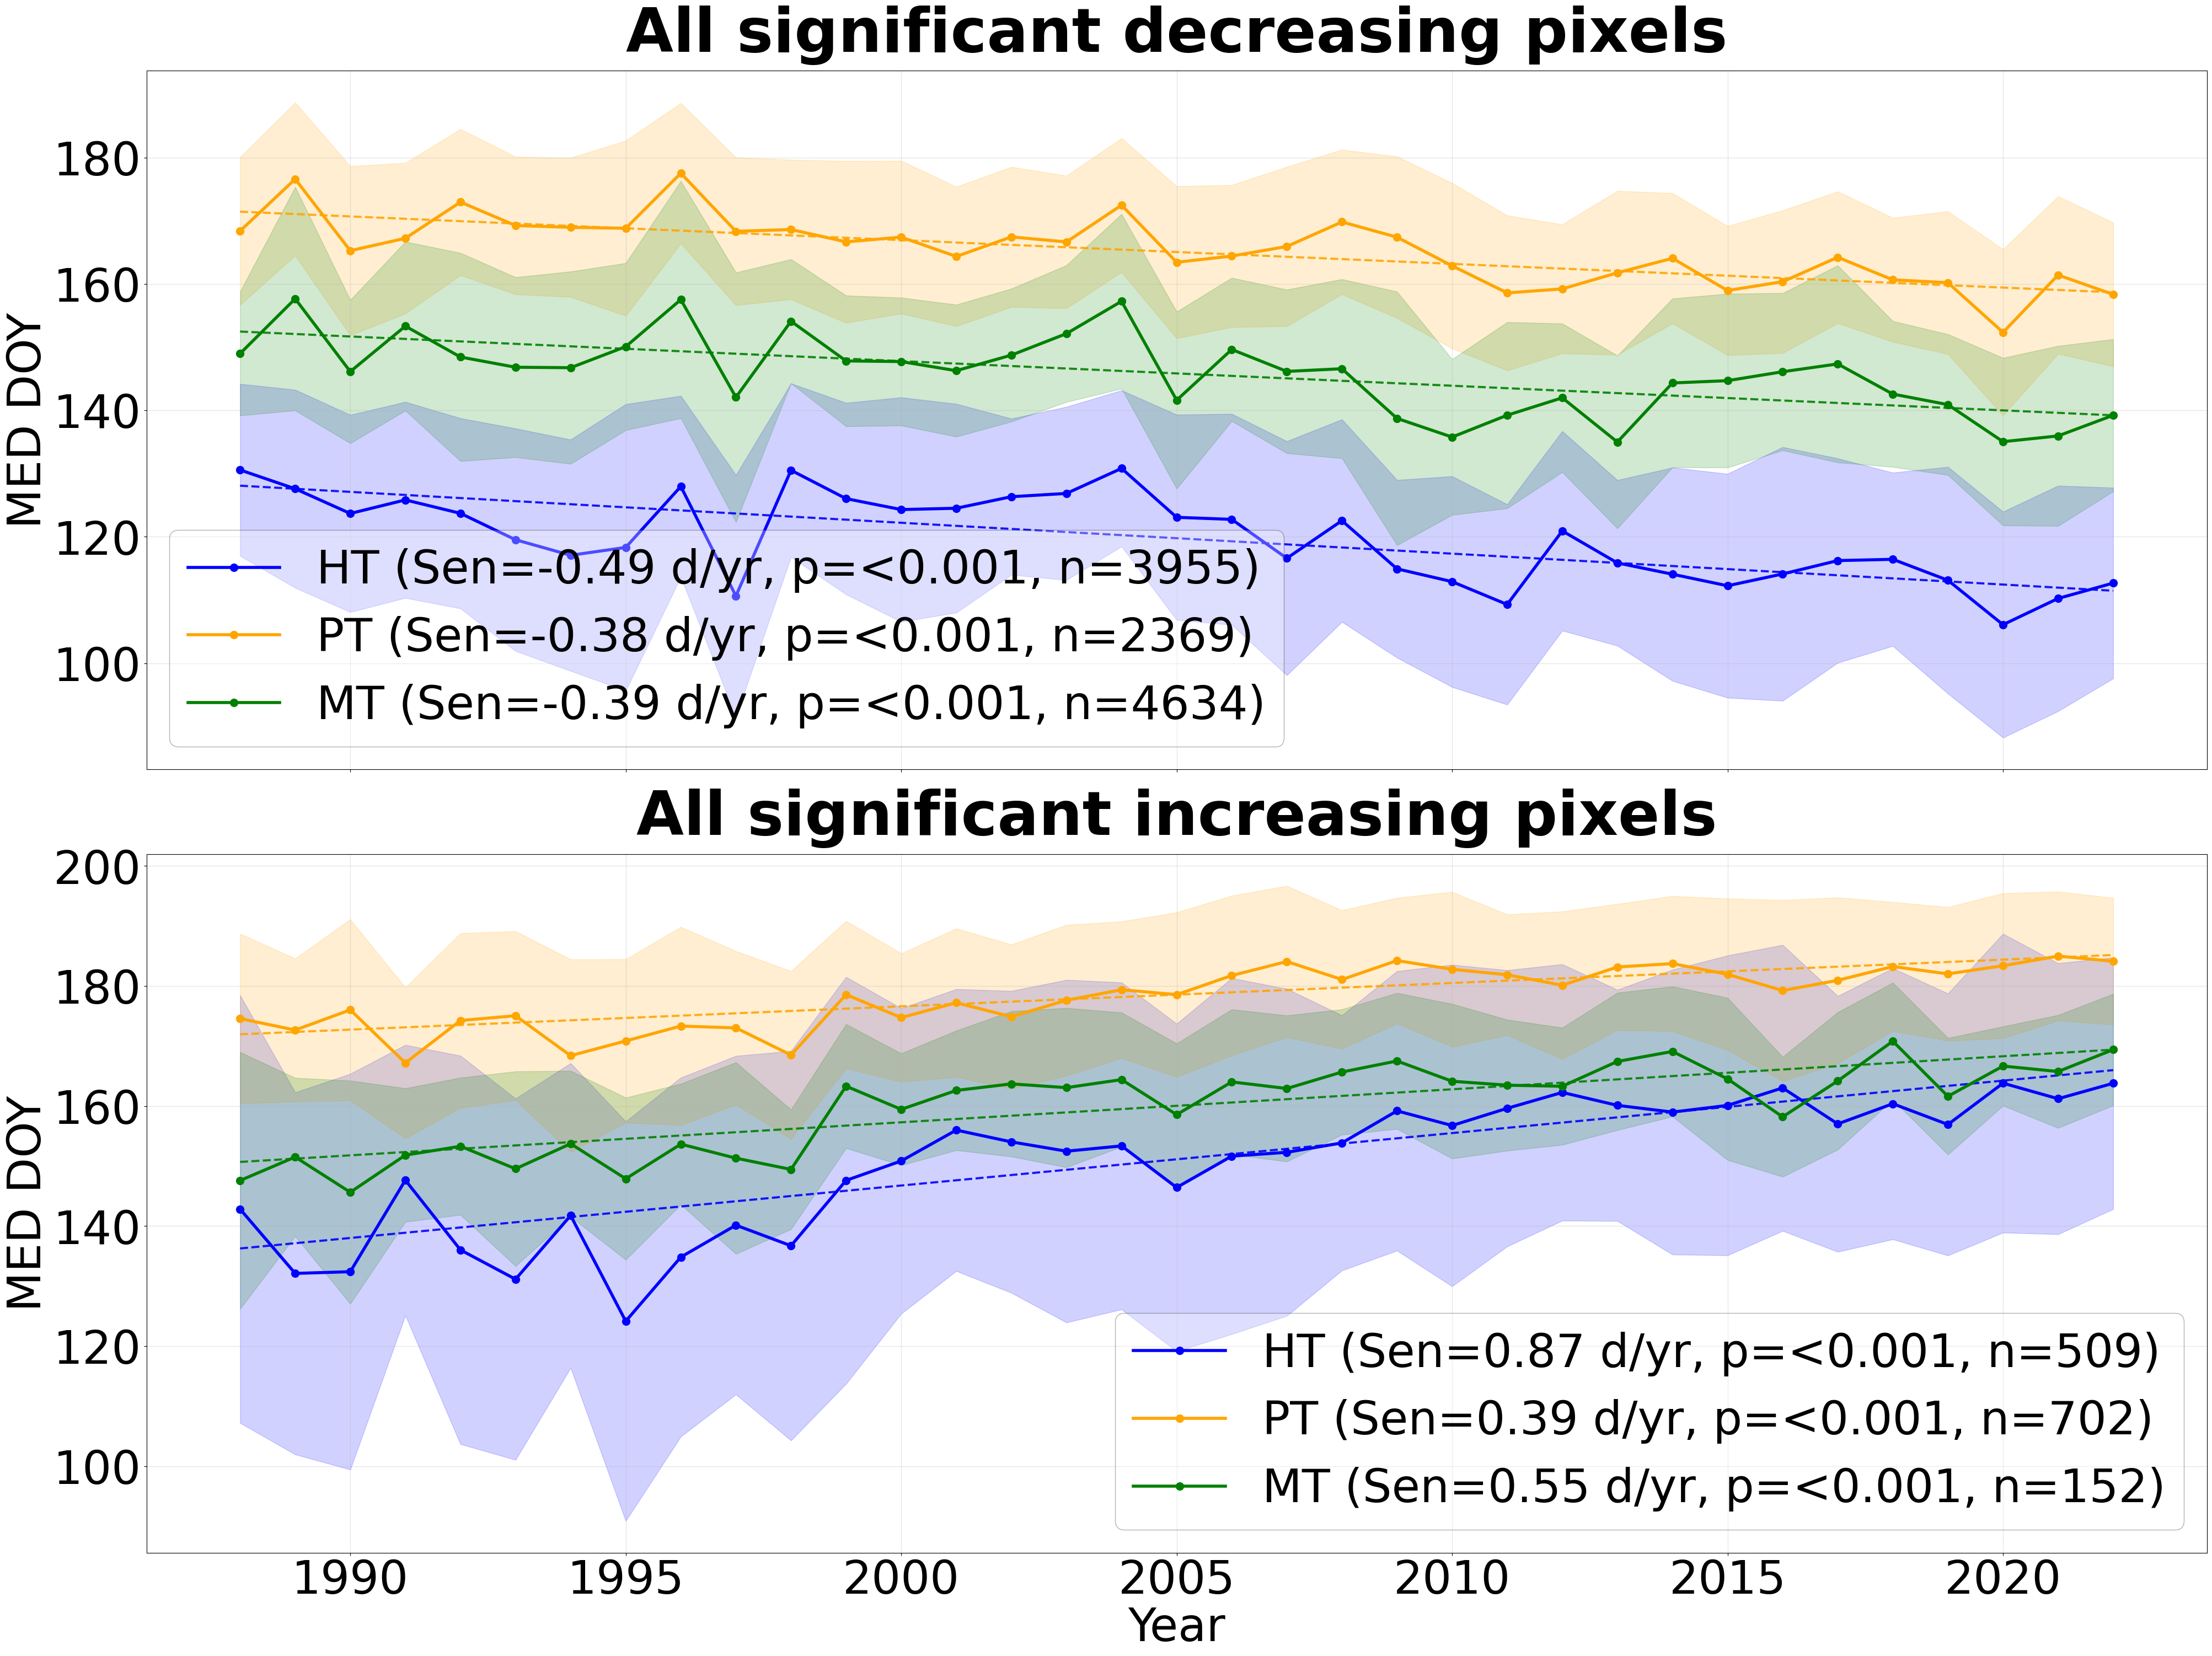

In [13]:
fig, axes = plot_all_significant_trend_pixels_by_regime(
    md_data=MED_doy,
    years=np.arange(1988, 2023),
    slope=mk_slope_med,
    p_value=mk_p_med,
    trend=mk_trend_med,
    cluster_map=TB_cluster,
    cluster_name_map=cluster_name_map,
    significant_level=0.05,
    error_type="std",
    title=None,
    ylabel="MED DOY",
    save_path=f"{out_dir}/MED_all_significant_increasing_decreasing_pixels_by_regime.png"
)

### Figure 3e. Plot the p-value map, showing only statistically significant values

In [14]:
# Divide the pvalue into 0.01, 0.05 and 0.2
mk_p_med_class = np.full_like(mk_p_med, np.nan)

mk_p_med_class[mk_p_med <= 0.01] = 0
mk_p_med_class[(mk_p_med > 0.01) & (mk_p_med <= 0.05)] = 1
mk_p_med_class[(mk_p_med > 0.05) & (mk_p_med <= 0.2)] = 2
mk_p_med_class[mk_p_med > 0.2] = 3

color_list = [
    "#b2182b",
    "#5ec962",
    "#fde725",
    "#d9d9d9"
]

cmap = mcolors.ListedColormap(color_list)

bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
ticks = [0, 1, 2, 3]
ticklabels = ["≤0.01", "0.01–0.05", "0.05–0.2", ">0.2"]

fig, ax = plot_Northpole(
    domain_lon, domain_lat, mk_p_med_class,
    label_title=None,
    cmap=cmap,
    bounds=bounds,
    ticks=ticks,
    ticklabels=ticklabels
)

fig.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/MED_pvalue_map.png", dpi=300, bbox_inches="tight")
plt.close(fig)


### Figure S5b. Cluster-averaged time series of Pettitt-derived MED over the 35-year period (1988–2022)

## 3. Melt Duration (MED - MOD) Trend Analysis 

In [15]:
# Define the start and end year
start_year, end_year = 1988, 2022
min_years = 30

# Exclude cluster 3 
MOD_doy[TB_cluster == 3, :] = np.nan
MED_doy[TB_cluster == 3, :] = np.nan

# Exclude DOY < 30 and DOY > 250 for MOD, and DOY > 250 for MED
MOD_doy[(MOD_doy < 30) | (MOD_doy > 250)] = np.nan
MED_doy[MED_doy > 250] = np.nan
invalid_mask = np.isnan(MOD_doy) | np.isnan(MED_doy)
MOD_doy[invalid_mask] = np.nan
MED_doy[invalid_mask] = np.nan

Duration_doy = MED_doy - MOD_doy

for yi, year in enumerate(range(start_year, end_year+1)):
    bad = (load_mask_for_year(year) == 0)
    slice_y = Duration_doy[:, :, yi]
    slice_y[bad] = np.nan
    Duration_doy[:, :, yi] = slice_y

lat_n, lon_n = Duration_doy.shape[:2]
mk_tau_duration   = np.full((lat_n, lon_n), np.nan)
mk_p_duration     = np.full((lat_n, lon_n), np.nan)
mk_trend_duration = np.full((lat_n, lon_n), 0, dtype=np.int8)  
mk_slope_duration = np.full((lat_n, lon_n), np.nan)            # Sen’s slope (days/year)

for i in range(lat_n):
    for j in range(lon_n):
        series = Duration_doy[i, j, :]
        valid = ~np.isnan(series)
        if np.count_nonzero(valid) < min_years:
            continue
        try:
            res = original_test(series[valid])
            mk_tau_duration[i, j]   = res.Tau
            mk_p_duration[i, j]     = res.p
            mk_trend_duration[i, j] = 1 if res.trend == 'increasing' else (-1 if res.trend == 'decreasing' else 0)
            mk_slope_duration[i, j] = res.slope      
        except Exception:
            pass

### Figure 3c. Sen’s slope of Pettitt-derived Melt Duration, shown only for pixels significant at the 95% confidence level (p < 0.05)

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/Pettitt_Duration_SenSlope_95percent.png
Mean slope for 95% significant Duration (MED - MOD) (days/year): -0.43623659143110755
Median slope for 95% significant Duration (MED - MOD) (days/year): -0.5666666666666667
Total significant pixels (p < 0.05): 6010
Number of decreasing pixels: 5094
Number of increasing pixels: 909
Number of no-trend pixels: 7


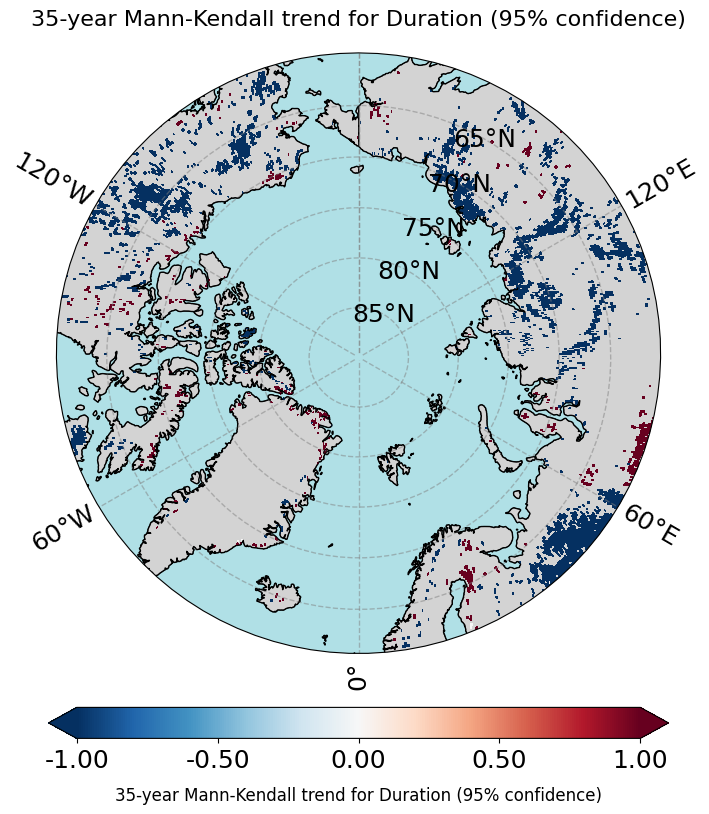

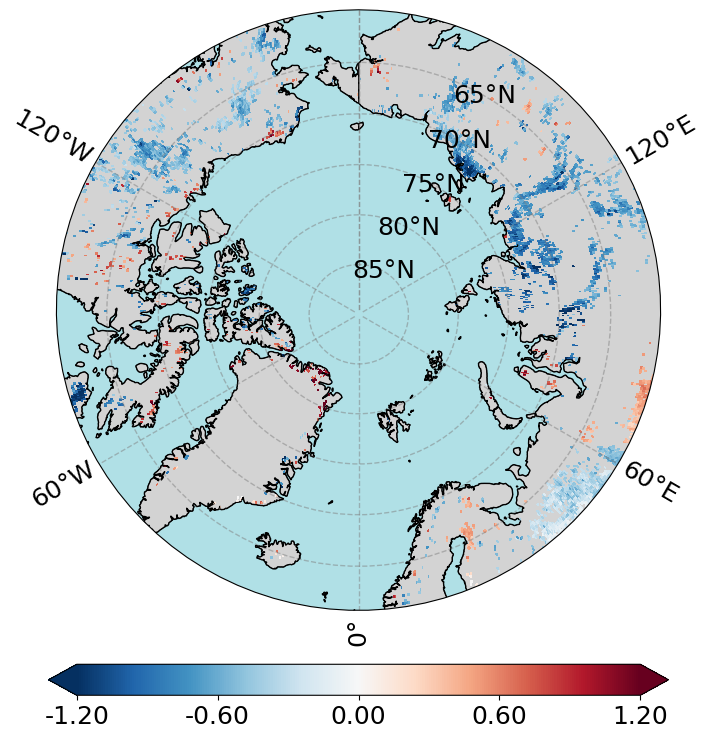

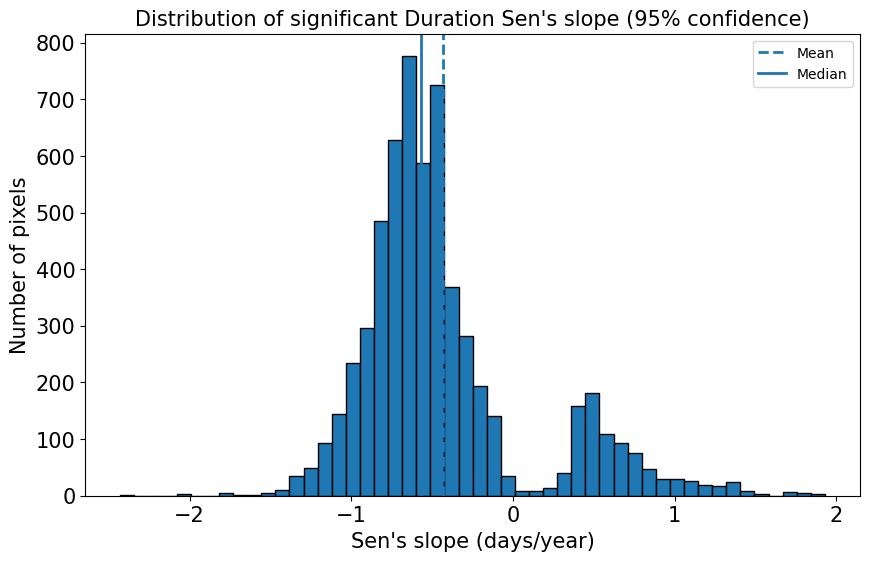

Total pixels in histogram: 6010


In [16]:
domain_lon, domain_lat = np.meshgrid(lon, lat)

# 1. Set significance level
significant_level_duration = 0.05
confidence_level_duration = int((1 - significant_level_duration) * 100)

# 2. Redefine significant trend direction using p-value and Sen's slope sign
mk_trend_redefined_duration = np.full(mk_slope_duration.shape, np.nan, dtype=float)

mk_trend_redefined_duration[
    (mk_p_duration < significant_level_duration) & (mk_slope_duration < 0)
] = -1

mk_trend_redefined_duration[
    (mk_p_duration < significant_level_duration) & (mk_slope_duration > 0)
] = 1

mk_trend_redefined_duration[
    (mk_p_duration < significant_level_duration) & (mk_slope_duration == 0)
] = 0

# 3. Plot trend direction
fig_trend_duration, ax_trend_duration = plot_Northpole(
    domain_lon,
    domain_lat,
    mk_trend_redefined_duration,
    label_title=f"35-year Mann-Kendall trend for Duration ({confidence_level_duration}% confidence)",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    vcenter=0
)

# 4. Plot Sen's slope with only significant pixels
mk_slope_significant_duration = np.where(
    mk_p_duration < significant_level_duration,
    mk_slope_duration,
    np.nan
)

fig_slope_duration, ax_slope_duration = plot_Northpole(
    domain_lon,
    domain_lat,
    mk_slope_significant_duration,
    label_title=None,
    cmap="RdBu_r",
    vmin=-1.2,
    vmax=1.2,
    vcenter=0
)

# 5. Save the slope figure
out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend"
out_png = os.path.join(
    out_dir,
    f"Pettitt_Duration_SenSlope_{confidence_level_duration}percent.png"
)

fig_slope_duration.savefig(
    out_png,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)

print("Saved:", out_png)

# 6. Statistics
slope_vals_duration = mk_slope_significant_duration[
    np.isfinite(mk_slope_significant_duration)
]

print(
    f"Mean slope for {confidence_level_duration}% significant Duration (MED - MOD) (days/year):",
    np.nanmean(slope_vals_duration)
)

print(
    f"Median slope for {confidence_level_duration}% significant Duration (MED - MOD) (days/year):",
    np.nanmedian(slope_vals_duration)
)

# 7. Count decreasing/increasing pixels
total_significant_pixels_duration = np.sum(np.isfinite(mk_trend_redefined_duration))
decreasing_pixels_duration = np.sum(mk_trend_redefined_duration == -1)
increasing_pixels_duration = np.sum(mk_trend_redefined_duration == 1)
no_trend_pixels_duration = np.sum(mk_trend_redefined_duration == 0)

print(f"Total significant pixels (p < {significant_level_duration}): {total_significant_pixels_duration}")
print(f"Number of decreasing pixels: {decreasing_pixels_duration}")
print(f"Number of increasing pixels: {increasing_pixels_duration}")
print(f"Number of no-trend pixels: {no_trend_pixels_duration}")

if total_significant_pixels_duration != (
    decreasing_pixels_duration + increasing_pixels_duration + no_trend_pixels_duration
):
    print(
        f"Warning: Total significant pixels (p < {significant_level_duration}) "
        "is not equal to the sum of decreasing/increasing/no-trend pixels"
    )

# 8. Histogram of significant Sen's slope values
plt.figure(figsize=(10, 6))
plt.hist(slope_vals_duration, bins=50, edgecolor="black")
plt.axvline(np.nanmean(slope_vals_duration), linestyle="--", linewidth=2, label="Mean")
plt.axvline(np.nanmedian(slope_vals_duration), linestyle="-", linewidth=2, label="Median")

plt.xlabel("Sen's slope (days/year)")
plt.ylabel("Number of pixels")
plt.title(
    f"Distribution of significant Duration Sen's slope "
    f"({confidence_level_duration}% confidence)"
)
plt.legend()
plt.show()

print("Total pixels in histogram:", slope_vals_duration.size)


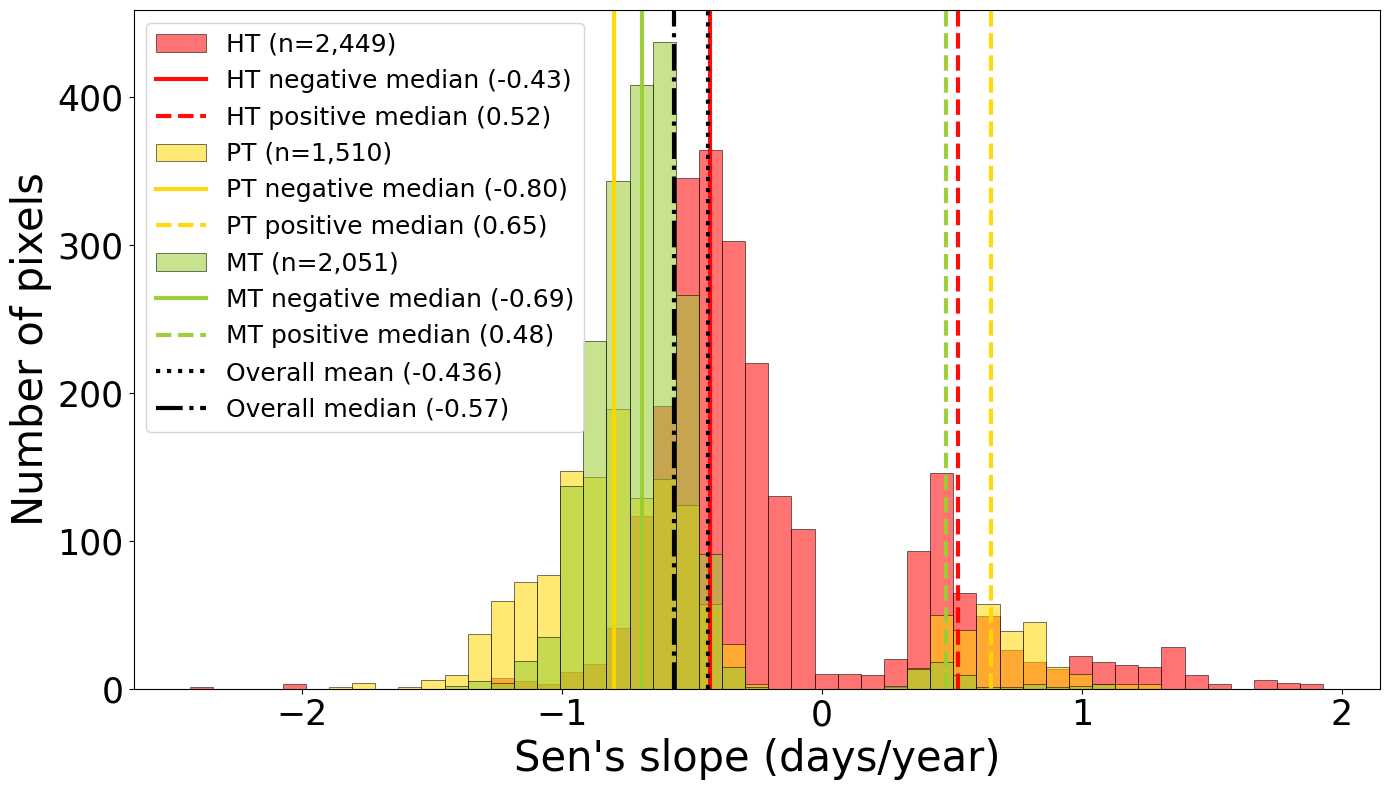

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/Duration_slope_95percent_histogram.png


In [54]:
out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend"

plot_slope_histogram_by_regime(
    mk_slope_significant=mk_slope_significant_duration,
    TB_cluster=TB_cluster,
    metric_name="Duration",
    confidence_level=confidence_level,
    out_dir=out_dir,
)

In [22]:
zero_mask = (
    (mk_p_duration < 0.05) &
    (mk_slope_duration == 0)
)

print(np.sum(zero_mask))

7


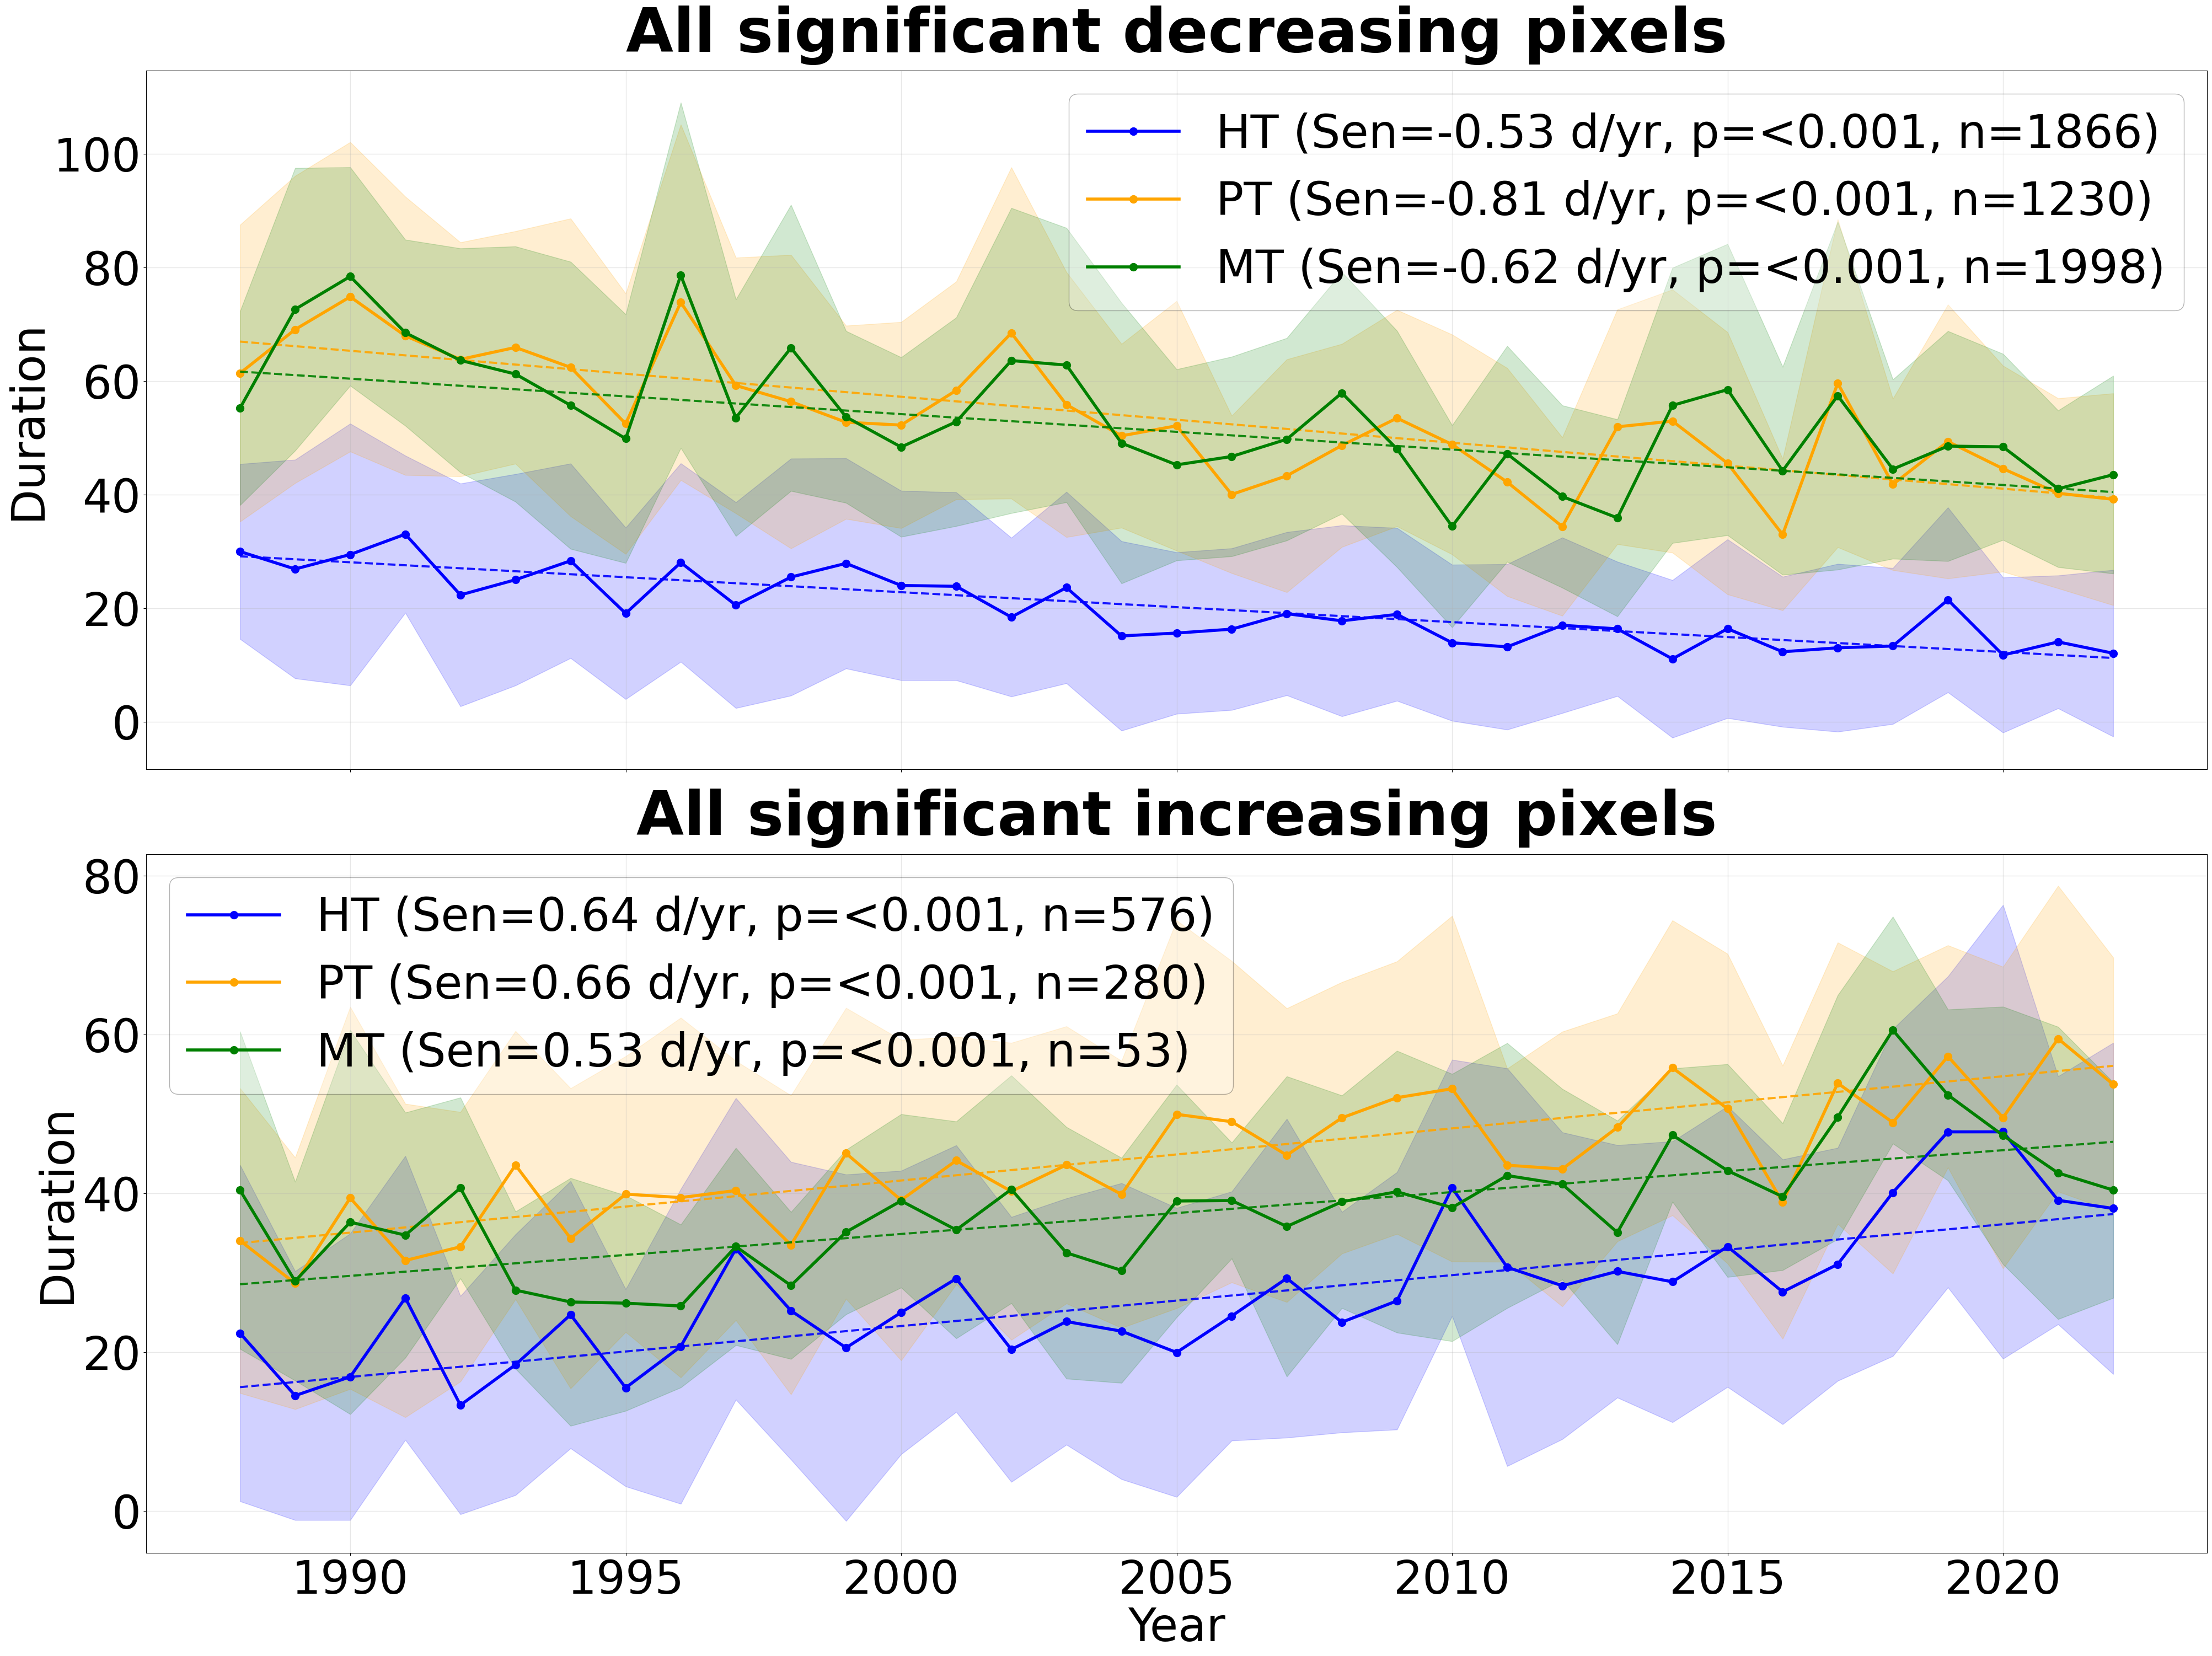

In [17]:
fig, axes = plot_all_significant_trend_pixels_by_regime(
    md_data=Duration_doy,
    years=np.arange(1988, 2023),
    slope=mk_slope_duration,
    p_value=mk_p_duration,
    trend=mk_trend_duration,
    cluster_map=TB_cluster,
    cluster_name_map=cluster_name_map,
    significant_level=0.05,
    error_type="std",
    title=None,
    ylabel="Duration",
    save_path=f"{out_dir}/Duration_all_significant_increasing_decreasing_pixels_by_regime.png"
)

### Figure 3f. Plot the p-value map, showing only statistically significant values

In [18]:
# Divide the pvalue into 0.01, 0.05 and 0.2
mk_p_duration_class = np.full_like(mk_p_duration, np.nan)

mk_p_duration_class[mk_p_duration <= 0.01] = 0
mk_p_duration_class[(mk_p_duration > 0.01) & (mk_p_duration <= 0.05)] = 1
mk_p_duration_class[(mk_p_duration > 0.05) & (mk_p_duration <= 0.2)] = 2
mk_p_duration_class[mk_p_duration > 0.2] = 3

color_list = [
    "#b2182b",
    "#5ec962",
    "#fde725",
    "#d9d9d9"
]

cmap = mcolors.ListedColormap(color_list)

bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
ticks = [0, 1, 2, 3]
ticklabels = ["≤0.01", "0.01–0.05", "0.05–0.2", ">0.2"]

fig, ax = plot_Northpole(
    domain_lon, domain_lat, mk_p_duration_class,
    label_title=None,
    cmap=cmap,
    bounds=bounds,
    ticks=ticks,
    ticklabels=ticklabels
)

# Save the figure
fig.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Trend/Duration_pvalue_map.png", dpi=300, bbox_inches="tight")
plt.close(fig)